In [2]:
from unstructured.partition.pdf import partition_pdf
from IPython.display import Image, display
import base64
import pandas as pd
import io
import tabulate
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
from collections import defaultdict
import json
import psycopg2
from pgvector.psycopg2 import register_vector
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
from ragas.testset import TestsetGenerator
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_community.document_loaders import PyPDFLoader
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
from ragas import RunConfig
import numpy as np
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_openai import ChatOpenAI
from langchain_core.rate_limiters import InMemoryRateLimiter
from docling.document_converter import DocumentConverter





C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_18224\851817018.py:23: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_18224\851817018.py:23: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_18224\851817018.py:23: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Exam

In [3]:
load_dotenv()

True

In [4]:
rate_limiter = InMemoryRateLimiter(
    requests_per_second=7,
    check_every_n_seconds=0.1,
    max_bucket_size=10
)

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, rate_limiter=rate_limiter)

In [6]:
# gemini embedding 2 preview is layout aware and can recognise table markdown as a relational grid. 
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-2-preview"
)

In [25]:
chunks = partition_pdf(
    filename="pdfs/government-data-security-policies.pdf",
    strategy="hi_res", # table detection and extraction as text_as_html

    infer_table_structure=True,
    extract_image_block_types=["Image", "Table"],
    extract_image_block_to_payload=True, # extracts images and tables as base64 encoded strings

    chunking_strategy="by_title",
    max_characters=2500,
    combine_text_under_n_chars=1000,
    new_after_n_chars=2000
)
'''chunk by title chunks by section headings and titles. For structured documents, each document
element is already semantically sound. computaionally cheaper than semantic chunking which is more 
suitable for highly unstructured data. 
'''

'chunk by title chunks by section headings and titles. For structured documents, each document\nelement is already semantically sound. computaionally cheaper than semantic chunking which is more \nsuitable for highly unstructured data. \n'

In [31]:
chunks[15].metadata.orig_elements

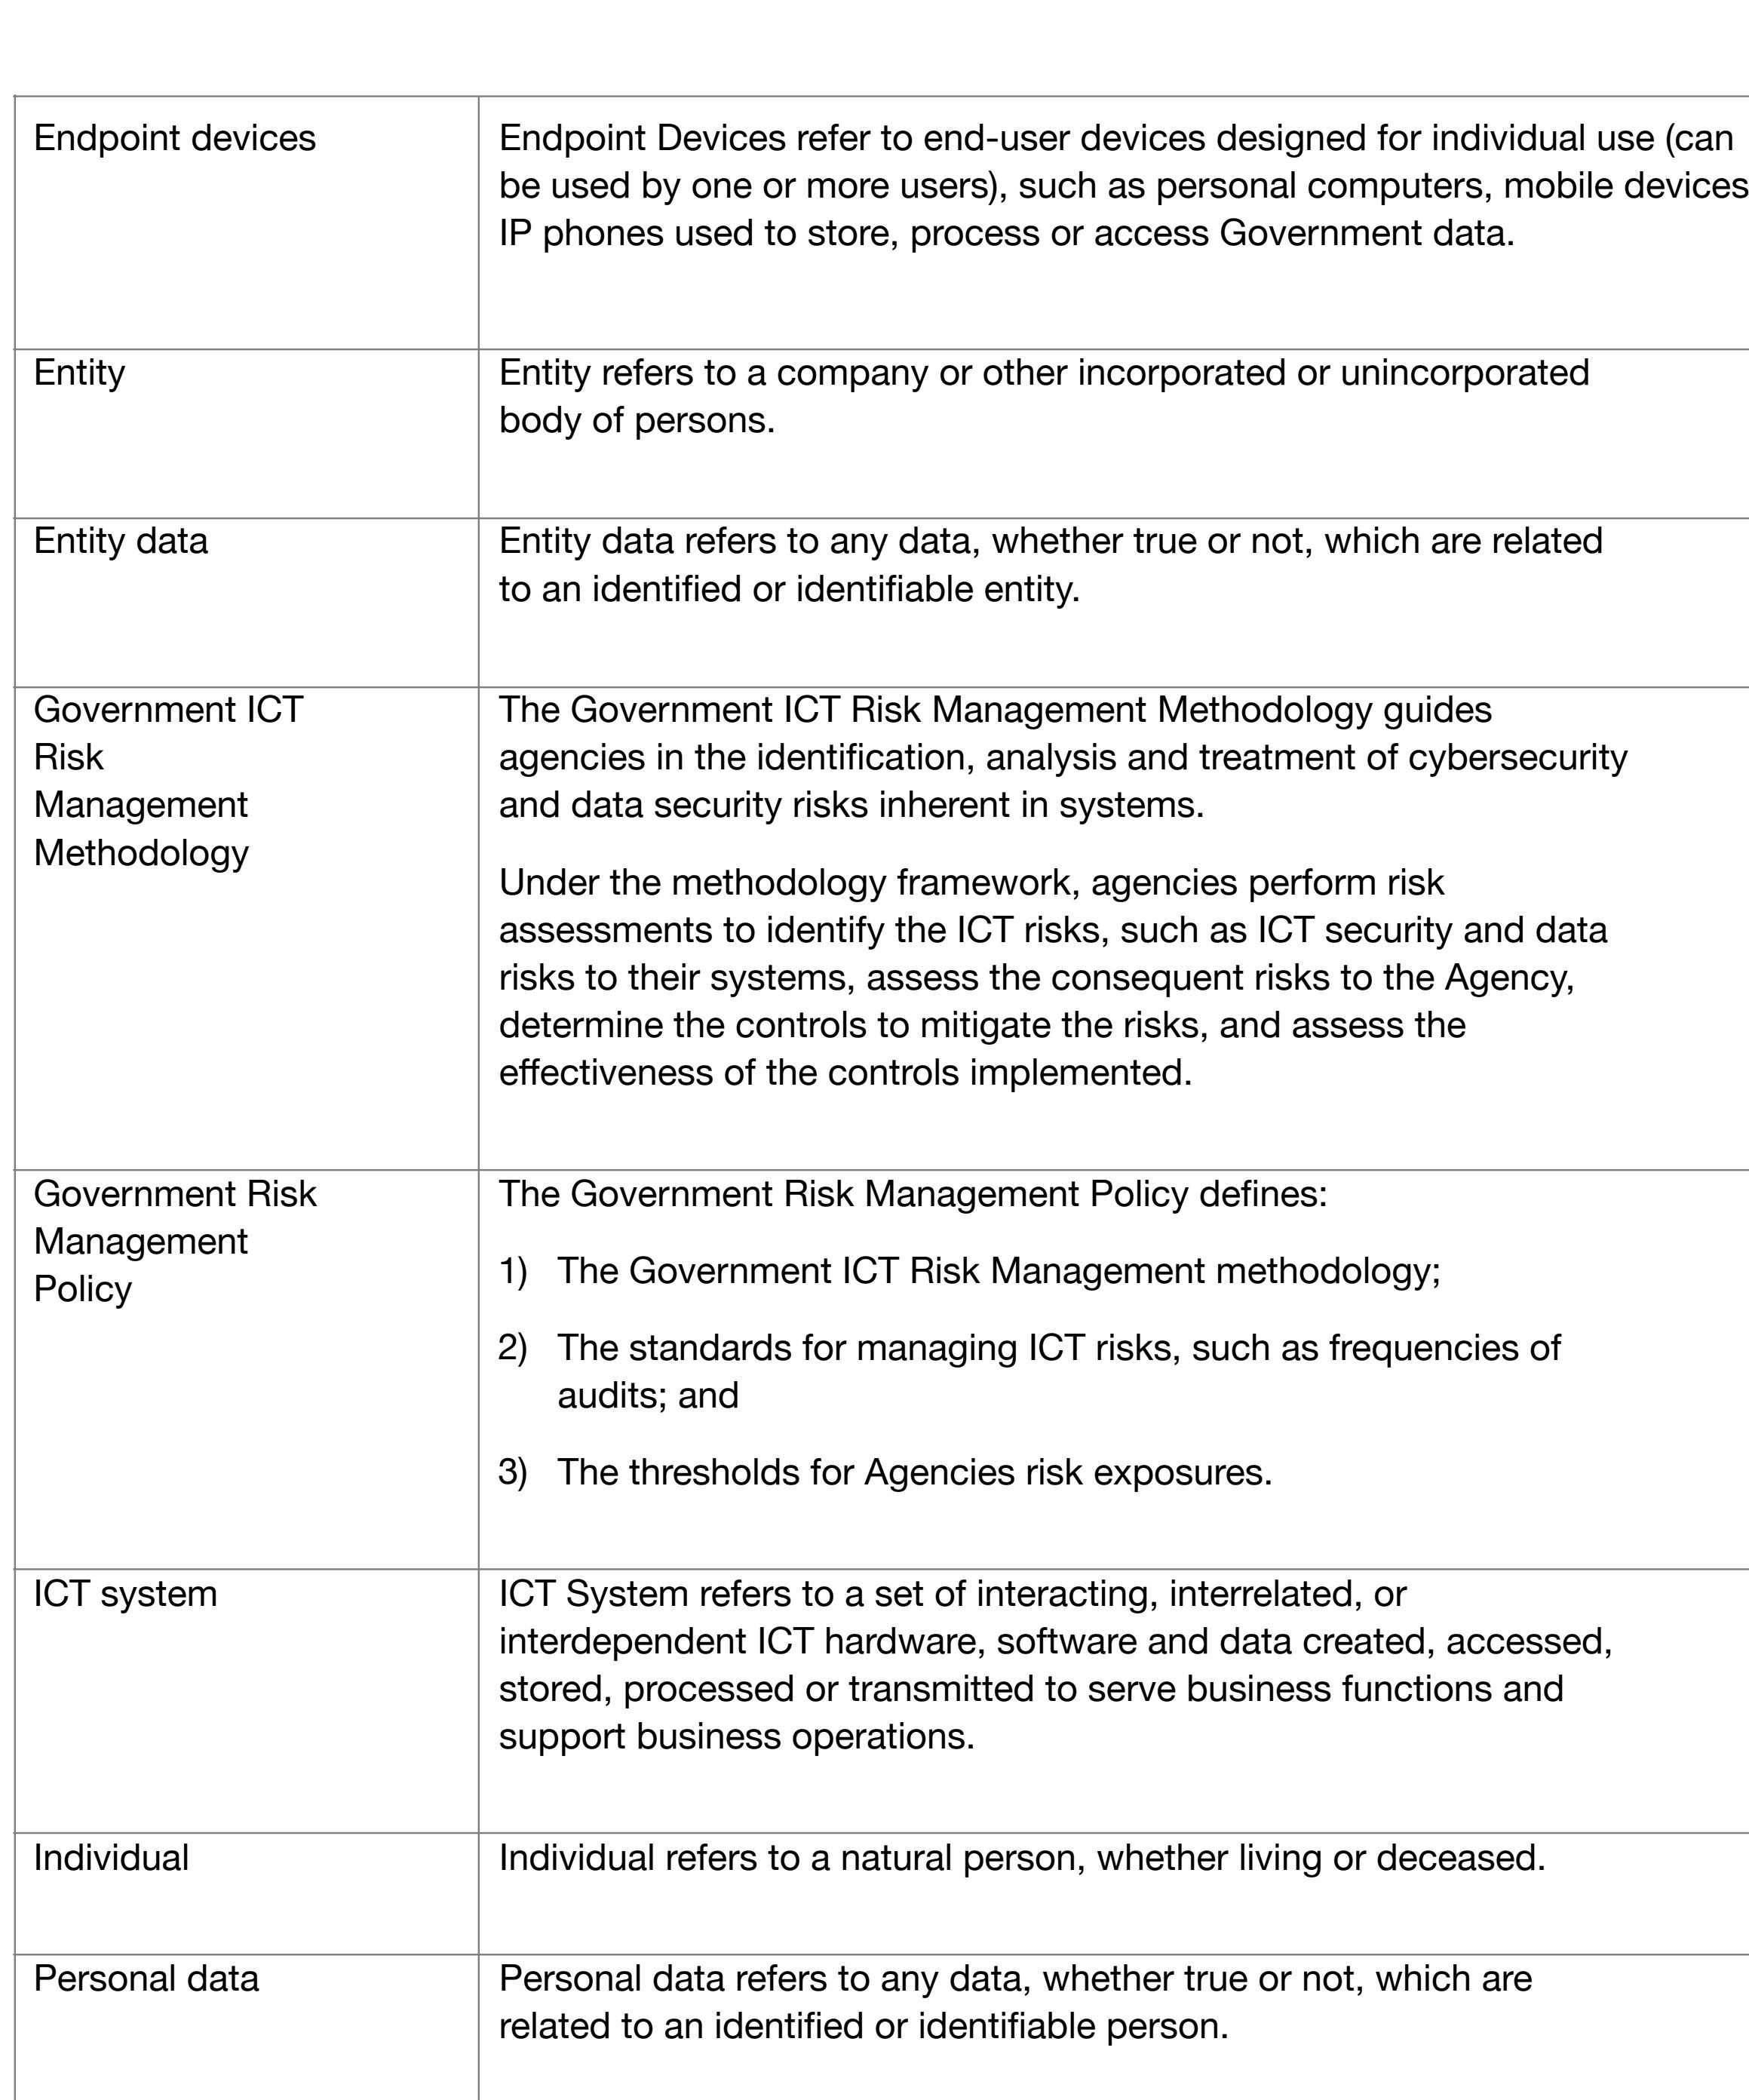

In [32]:
string = chunks[15].metadata.orig_elements[0].metadata.image_base64
display(Image(data=base64.b64decode(string)))

In [78]:
'''loops through each element in chunk. If element is table, converts text_as_html to markdown
which is generally better (lower token cost, more readable to llms)
'''
def modify_text(chunk):
    text = []
    for element in chunk.metadata.orig_elements:
        if element.category == "Table" and getattr(element.metadata, "text_as_html", None):
            df = pd.read_html(io.StringIO(element.metadata.text_as_html))[0]
            markdown = df.to_markdown(index=False)
            text.append(markdown)
        else:
            text.append(element.text)
    chunk.text = "\n\n".join(text)

In [79]:
def extract_coords(chunk):
    highlights = []
    orig_elements = chunk.metadata.orig_elements
    for element in orig_elements:
        page = element.metadata.page_number
        coords = element.metadata.coordinates.points

        width = element.metadata.coordinates.system.width
        height = element.metadata.coordinates.system.height

        xs = [p[0] for p in coords]
        ys = [p[1] for p in coords]
    
        clean_box = [
            round(max(0, float(min(xs))),2),
            round(max(0, float(min(ys))),2),
            round(min(width, float(max(xs))), 2),
            round(min(height, float(max(ys))), 2)
        ]
        highlights.append({
            "page": int(page),
            "bbox": clean_box,
            "width": int(width),
            "height": int(height)
        })
    setattr(chunk.metadata, "highlights", highlights)

In [80]:
def embed_text(chunk):
    vector = embeddings.embed_query(chunk.text)
    setattr(chunk.metadata, "vector", vector)

In [81]:
def number_chunk(chunk, number):
    setattr(chunk.metadata, "chunk_number", number)


In [82]:
def process_chunk(chunk, number):
    modify_text(chunk)
    embed_text(chunk)
    extract_coords(chunk)
    number_chunk(chunk, number)

In [83]:
for index, chunk in enumerate(chunks):
    process_chunk(chunk, index + 1)

In [18]:
import fitz
def visualize_chunk_highlights(pdf_path, chunk, output_path="preview.pdf"):
    doc = fitz.open(pdf_path)
    highlights = getattr(chunk.metadata, "highlights", [])

    for h in highlights:
        page_index = h['page'] - 1
        page = doc[page_index]
        
        # 1. Get the page size as PyMuPDF sees it (72 DPI)
        actual_w = page.rect.width
        actual_h = page.rect.height
        
        # 2. Get the original system size from your metadata
        orig_w = h['width']
        orig_h = h['height']
        
        # 3. SCALE the coordinates
        # Math: (Raw_Value / Original_System_Size) * Actual_PDF_Size
        raw_bbox = h['bbox'] # [x1, y1, x2, y2]
        
        scaled_bbox = [
            (raw_bbox[0] / orig_w) * actual_w, # x_min
            (raw_bbox[1] / orig_h) * actual_h, # y_min
            (raw_bbox[2] / orig_w) * actual_w, # x_max
            (raw_bbox[3] / orig_h) * actual_h  # y_max
        ]
        
        # 4. Draw the correctly scaled rectangle
        rect = fitz.Rect(scaled_bbox)
        page.draw_rect(rect, color=(1, 1, 0), fill=(1, 1, 0), overlay=True, width=0)

    doc.save(output_path)
visualize_chunk_highlights("government-data-security-policies.pdf", chunks[1], output_path="preview.pdf")

In [84]:
print(chunks[20].text)

| 0                       | 1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
|:------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------

In [85]:
chunks[20].metadata.highlights

[{'page': 22,
  'bbox': [234.95, 292.45, 2614.08, 3050.35],
  'width': 2894,
  'height': 4093}]

In [21]:
chunks[20].metadata.chunk_number

21

docker exec -it pgvector-db psql -U postgres

In [10]:
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="rag_db",
    user="postgres"
)
register_vector(conn)
cur = conn.cursor()

In [9]:
chunk = chunks[0]
chunk_embedding = chunk.metadata.vector
chunk_text = chunk.text
if chunk.metadata.image_base64:
    image_base64 = base64.b64decode(chunk.metadata.image_base64)
else: 
    image_base64 = None
highlights = chunk.metadata.highlights

NameError: name 'chunks' is not defined

In [16]:
try:
    cur.execute('''
        INSERT INTO chunk_store (chunk_embedding, chunk_text, image_base64, highlights)
        VALUES (%s, %s, %s, %s)
    ''', (chunk_embedding, chunk_text, image_base64, json.dumps(highlights)))
    conn.commit()
except Exception as e: 
    print(f"Postgres Error: {e}")
    conn.rollback()

In [22]:
def store_chunk(chunk):
    chunk_embedding = chunk.metadata.vector
    chunk_text = chunk.text
    if chunk.metadata.image_base64:
        image_base64 = base64.b64decode(chunk.metadata.image_base64)
    else: 
        image_base64 = None
    highlights = chunk.metadata.highlights
    chunk_number = chunk.metadata.chunk_number
    try:
        cur.execute('''
            INSERT INTO chunk_store (chunk_embedding, chunk_text, image_base64, highlights, chunk_number)
            VALUES (%s, %s, %s, %s, %s)
        ''', (chunk_embedding, chunk_text, image_base64, json.dumps(highlights), chunk_number))
        conn.commit()
    except: 
        print("Error")
        conn.rollback()

In [88]:
for chunk in chunks:
    store_chunk(chunk)

In [4]:
cur.execute("SELECT chunk_text FROM chunk_store WHERE chunk_number = 1")
data = cur.fetchall()
data

[("GOVERNMENT DATA SECURITY POLICIES\nThis document contains general information for the public only. It is not intended to be relied upon as a comprehensive or definitive guide on each agency's policies and practices. The data security measures implemented by each agency will differ depending on various factors such as the sensitivity of the data and the agency's assessment of data security risks. The Government may update the policies set out in this document without publishing such updates to the public.\nGovernment Data Security Policies\n|\n\n1",)]

In [107]:
query = "data security risk management"

In [11]:
def search_chunks(query):
    query_vector = embeddings.embed_query(query)
    search_query = '''
        SELECT chunk_number, chunk_text, 1 - (chunk_embedding <=> %s) AS similarity
        FROM chunk_store
        ORDER BY chunk_embedding <=> %s
        LIMIT 5;
    '''
    try:
        cur.execute(search_query, (str(query_vector), str(query_vector)))
        data = cur.fetchall()
        df = pd.DataFrame(data, columns=["chunk_number", "chunk_text", "similarity"])
        return df
    except Exception as e:
        print(f"An error occurred: {e}")
        conn.rollback()
    

In [112]:
df = search_chunks(query)

In [113]:
df.head()


,chunk_number,chunk_text,similarity
0,3,Section 1: Data Security Risk Management\n- 01...,0.736845
1,36,Technical measures and the process measures\nV...,0.695734
2,2,The Government takes its responsibility as a c...,0.687110
3,4,Section 2: Technical and process measures to p...,0.685838
4,38,"Glossary of Terms\nAgency, Definition = Agency...",0.685009


In [93]:
def filter(df, threshold=0.1):
    max_similarity = df.iloc[0]["similarity"]
    mask = df["similarity"] >= (max_similarity - threshold)

    final_df = df[mask]
    return final_df

In [22]:
def filter1(query, df, threshold=0.1):
    max_similarity = df.iloc[0]["similarity"]
    mask = df["similarity"] >= (max_similarity - threshold)
    df = df[mask]

    reranker_model = CrossEncoder('BAAI/bge-reranker-v2-m3')
    reranker_model.tokenizer.pad_token = reranker_model.tokenizer.eos_token
    reranker_model.model.config.pad_token_id = reranker_model.model.config.eos_token_id
    pairs = [[query, chunk_text] for chunk_text in df["chunk_text"]]
    df["rerank_score"] = reranker_model.predict(pairs)
    df = df.sort_values(by="rerank_score", ascending=False)

    return df


In [115]:
filter1(query, df)

,chunk_number,chunk_text,similarity,rerank_score
0,3,Section 1: Data Security Risk Management\n- 01...,0.736845,0.999192
2,2,The Government takes its responsibility as a c...,0.687110,0.951504
3,4,Section 2: Technical and process measures to p...,0.685838,0.587114
4,38,"Glossary of Terms\nAgency, Definition = Agency...",0.685009,0.503361
1,36,Technical measures and the process measures\nV...,0.695734,0.275066


In [116]:
lis = df["chunk_text"].tolist()
lis

['Section 1: Data Security Risk Management\n- 01 To  ensure  adequate  and  effective  data  security  risk  management,  Agencies  should perform data security risk assessments for their datasets, as part of the Government ICT Risk Management Methodology.\nThis  will  enable  Agencies  to  identify  data  security  risks,  evaluate  the  risks,  implement measures to mitigate the risks, assess the effectiveness of the implemented measures and manage the risks within limits acceptable to the Agency.\n- 02 Agencies should use the Data Security Risk Assessment Methodology, which is part of the  Government  ICT  Risk  Management  Methodology,  to  conduct  data  security  risk assessments for their datasets.\n- 03 Agencies should conduct a data security risk assessment:\n- a) When acquiring a new dataset;\n- b) Developing a new ICT system that contains personal or entity data; or\n- c) When existing data which has not been risk assessed is first used.\n- 04 Agencies should review the data

In [28]:
cur.close()
conn.close()

In [23]:
def generate_context(dataframe):
    context_text = "\n\n".join(
        f"--- Chunk {row['chunk_number']} ---\n{row['chunk_text']}"
        for _, row in dataframe.iterrows()
    )
    return context_text

In [118]:
context_text = generate_context(df)

In [24]:
def generate_message(query, context_text):
    messages = [SystemMessage(content="""
    You are a professional assistant. Your goal is to provide accurate answers based ONLY on the provided context chunks.

    RULES:
    1. GROUNDING: If the answer is not contained within the provided context, state clearly that you do not have enough information. Do not use external knowledge.
    2. CITATIONS: You MUST cite the specific Chunk Number (e.g. [Chunk 4]) for every fact or claim you make. Each chunk is labelled at the start (e.g. --- Chunk 4 ---).
    3. CONTEXT INTEGRATION: Treat the chunks as a single unified knowledge base, even if they are provided out of chronological order.
    4. RELEVANCE: Only use information from chunks that are relevant to answering the question.  
    5. TABLES: If context contains Markdown tables, interpret row-to-column relationships strictly to ensure data accuracy.
    6. FORMATTING: Use clear headings and bullet points for complex answers.                          
    """),
    HumanMessage(content=f"""
    Context: 
    {context_text}

    Question: {query}
    """),

    ]
    return messages

In [99]:
messages = generate_message(query, context_text)

In [100]:
print(messages)

[SystemMessage(content='\n    You are a professional assistant. Your goal is to provide accurate answers based ONLY on the provided context chunks.\n\n    RULES:\n    1. GROUNDING: If the answer is not contained within the provided context, state clearly that you do not have enough information. Do not use external knowledge.\n    2. CITATIONS: You MUST cite the specific Chunk Number (e.g. [Chunk 4]) for every fact or claim you make. Each chunk is labelled at the start (e.g. --- Chunk 4 ---).\n    3. CONTEXT INTEGRATION: Treat the chunks as a single unified knowledge base, even if they are provided out of chronological order.\n    4. RELEVANCE: Only use information from chunks that are relevant to answering the question.  \n    5. TABLES: If context contains Markdown tables, interpret row-to-column relationships strictly to ensure data accuracy.\n    6. FORMATTING: Use clear headings and bullet points for complex answers.                          \n    ', additional_kwargs={}, response_

In [112]:
response = llm.invoke(messages)

NameError: name 'llm' is not defined

In [61]:
print(response.content)

### Data Security Risk Management

#### Overview
Data security risk management is a critical aspect of ensuring that agencies adequately protect their datasets. The Government ICT Risk Management Methodology provides a framework for this process.

- **Purpose**: To identify, evaluate, mitigate, and manage data security risks within acceptable limits to the agency [Chunk 3].
- **Methodology**: Agencies should use the Data Security Risk Assessment Methodology, which is part of the Government ICT Risk Management Methodology [Chunk 3].

#### When to Conduct a Data Security Risk Assessment
Agencies are required to conduct a data security risk assessment under specific circumstances:

- When acquiring a new dataset.
- When developing a new ICT system that contains personal or entity data.
- When existing data, which has not been risk assessed, is first used [Chunk 3].

#### Reviewing Data Security Risk Assessments
Data security risk assessments should be reviewed periodically and under certa

In [15]:
ragas_llm = LangchainLLMWrapper(ChatOllama(
    model="llama3-groq-tool-use",
    format="json",
    temperature=0,
    num_ctx=8192
))
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_15808\4180710712.py:1: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(ChatOllama(
C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_15808\4180710712.py:7: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)


In [25]:
test_df = pd.read_csv("ragas_testset.csv")
test_df

,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,What is the intended audience for the Governme...,['Government Data Security Policies | \x001...,The Government Data Security Policies document...,Information Security Analyst,WEB_SEARCH_LIKE,MEDIUM,single_hop_specific_query_synthesizer
1,Wht are the key policies in the Govenment's da...,['The Government takes its responsibility as a...,The key policies in the Government's data secu...,Data Security Analyst,MISSPELLED,LONG,single_hop_specific_query_synthesizer
2,What steps should agencies take for effective ...,['Section 1: Data Security Risk Management\n01...,To ensure adequate and effective data security...,Information Security Analyst,WEB_SEARCH_LIKE,MEDIUM,single_hop_specific_query_synthesizer
3,How can agencies minimize the surface area of ...,['Section 3: Reduce the surface area of attack...,Agencies can minimize the surface area of atta...,Information Security Analyst,PERFECT_GRAMMAR,LONG,single_hop_specific_query_synthesizer
4,How do agencies log and monitor data transacti...,['<1-hop>\n\nSection 4: Log and monitor data \...,Agencies log and monitor data transactions to ...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
5,How do agencies log and monitor data transacti...,['<1-hop>\n\nSection 4: Log and monitor data \...,Agencies log and monitor data transactions to ...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
6,How do agencies log and monitor data transacti...,['<1-hop>\n\nSection 4: Log and monitor data \...,Agencies log and monitor data transactions to ...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
7,How do logging and monitoring of data transact...,['<1-hop>\n\nSection 4: Log and monitor data \...,Logging and monitoring of data transactions co...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
8,Wht are the key measures in governmnt data sec...,['<1-hop>\n\nGovernment Data Security Policies...,The key measures in government data security p...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer
9,Wht r privileged accnts and how do they relate...,['<1-hop>\n\nPrivileged \naccounts\nPrivileged...,Privileged accounts refer to accounts used by ...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer


In [26]:
evaluation_data = []
for index, row in test_df.iterrows():
    question = row.user_input
    ground_truth = row.reference

    retrieved_df = search_chunks(question)
    filtered_df = filter1(question, retrieved_df).copy()
    context_text = filtered_df["chunk_text"].tolist()

    context = generate_context(retrieved_df)
    messages = generate_message(question, context)
    response = llm.invoke(messages)

    evaluation_data.append({
        "question": question,
        "answer": response.content,
        "contexts": context_text,
        "ground_truth": ground_truth
    })
eval_dataset = Dataset.from_list(evaluation_data)
    

    

    

C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_15808\1168198744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rerank_score"] = reranker_model.predict(pairs)
C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_15808\1168198744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["rerank_score"] = reranker_model.predict(pairs)
C:\Users\UserAdmin\AppData\Local\Temp\ipykernel_15808\1168198744.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using 

In [27]:
df = eval_dataset.to_pandas()
df.head()

,question,answer,contexts,ground_truth
0,What is the intended audience for the Governme...,The intended audience for the Government Data ...,[GOVERNMENT DATA SECURITY POLICIES\nThis docum...,The Government Data Security Policies document...
1,Wht are the key policies in the Govenment's da...,The key policies in the Government's data secu...,[The Government takes its responsibility as a ...,The key policies in the Government's data secu...
2,What steps should agencies take for effective ...,To ensure effective Data Security Risk Managem...,[Section 1: Data Security Risk Management\n- 0...,To ensure adequate and effective data security...
3,How can agencies minimize the surface area of ...,Agencies can minimize the surface area of atta...,[Section 3: Reduce the surface area of attack ...,Agencies can minimize the surface area of atta...
4,How do agencies log and monitor data transacti...,Agencies can log and monitor data transactions...,[Section 4: Log and monitor data transactions ...,Agencies log and monitor data transactions to ...


In [ ]:
config = RunConfig(
    max_workers=4, 
    timeout=180,
    max_retries=2
)
metrics = [
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision
]
results = evaluate(
    dataset=eval_dataset,
    metrics=metrics,
    llm=llm,
    embeddings=ragas_embeddings,
    batch_size=2,
    run_config=config
)

Evaluating: 100%|██████████| 48/48 [11:16<00:00, 14.10s/it]


In [29]:
print(results)

{'faithfulness': 0.9102, 'answer_relevancy': 0.9639, 'context_recall': 0.9375, 'context_precision': 0.9906}


In [30]:
results_df = results.to_pandas()

In [31]:
results_df

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_recall,context_precision
0,What is the intended audience for the Governme...,[GOVERNMENT DATA SECURITY POLICIES\nThis docum...,The intended audience for the Government Data ...,The Government Data Security Policies document...,1.000000,0.991938,1.00,1.0000
1,Wht are the key policies in the Govenment's da...,[The Government takes its responsibility as a ...,The key policies in the Government's data secu...,The key policies in the Government's data secu...,0.666667,0.960150,1.00,1.0000
2,What steps should agencies take for effective ...,[Section 1: Data Security Risk Management\n- 0...,To ensure effective Data Security Risk Managem...,To ensure adequate and effective data security...,1.000000,0.966221,1.00,1.0000
3,How can agencies minimize the surface area of ...,[Section 3: Reduce the surface area of attack ...,Agencies can minimize the surface area of atta...,Agencies can minimize the surface area of atta...,0.846154,0.980555,0.50,1.0000
4,How do agencies log and monitor data transacti...,[Section 4: Log and monitor data transactions ...,Agencies can log and monitor data transactions...,Agencies log and monitor data transactions to ...,1.000000,0.948444,1.00,1.0000
5,How do agencies log and monitor data transacti...,[Enhanced logging and active monitoring of dat...,Agencies can log and monitor data transactions...,Agencies log and monitor data transactions to ...,1.000000,0.946106,1.00,1.0000
6,How do agencies log and monitor data transacti...,[Enhanced logging and active monitoring of dat...,Agencies can log and monitor data transactions...,Agencies log and monitor data transactions to ...,0.937500,0.949219,0.75,1.0000
7,How do logging and monitoring of data transact...,[Section 2: Technical and process measures to ...,Logging and monitoring of data transactions co...,Logging and monitoring of data transactions co...,0.909091,0.936516,1.00,1.0000
8,Wht are the key measures in governmnt data sec...,[The Government takes its responsibility as a ...,The key measures in government data security p...,The key measures in government data security p...,0.750000,0.985918,1.00,0.8875
9,Wht r privileged accnts and how do they relate...,"[Glossary of Terms\nPrivileged accounts, 1 = P...",### Privileged Accounts\n\nPrivileged accounts...,Privileged accounts refer to accounts used by ...,1.000000,0.955962,1.00,1.0000


In [38]:
results_df.iloc[1]["response"]

"The key policies in the Government's data security management as outlined in the IM on ICT&SS Management include:\n\n- **Data Security Requirements**: The policies prescribe data security requirements, including technical and process measures, to safeguard data against security threats [Chunk 2].\n- **Risk-Based Approach**: The technical and process measures are implemented using a risk-based approach. Agencies should select these measures based on the data security risk level, considering their operating contexts [Chunk 2].\n\nThese policies ensure that agencies manage data security effectively by assessing risks and implementing appropriate measures to mitigate them."

In [37]:
results_df.iloc[1]["reference"]

"The key policies in the Government's data security management, as outlined in the IM on ICT&SS Management, prescribe data security requirements, including technical and process measures to safeguard data against security threats. These measures are implemented using a risk-based approach, allowing agencies to select appropriate measures based on their data security risk level and operating contexts."